# Obtaining & exploring dataset

In [1]:
import numpy as np
import pandas as pd
import torch

In [2]:
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from pts.model.tempflow import TempFlowEstimator
from pts.model.transformer_tempflow import TransformerTempFlowEstimator
from pts import Trainer
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\json.py:101: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
c:\Users\shesh\anaconda3\envs\TempFlow\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = get_dataset("solar_nips", regenerate=False)
#dataset = get_dataset("traffic_nips", regenerate=False)


C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:324: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  timestamp = pd.Timestamp(timestamp_input, freq=freq)
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:327: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  if isinstance(timestamp.freq, Tick):
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:329: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  timestamp.floor(timestamp.freq), timestamp.freq
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:328: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  return pd.Timestamp(


saving time-series into C:\Users\shesh\.mxnet\gluon-ts\datasets\solar_nips\train\data.json
saving time-series into C:\Users\shesh\.mxnet\gluon-ts\datasets\solar_nips\test\data.json


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
device

device(type='cuda')


## Prepare dataset

In [6]:
train_grouper = MultivariateGrouper(max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

test_grouper = MultivariateGrouper(num_test_dates=int(len(dataset.test)/len(dataset.train)),
                                   max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

In [7]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:106: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  timestamp + (len(data[FieldName.TARGET]) - 1) * timestamp.freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:108: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self.frequency = timestamp.freq
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:217: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:166: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:177: FutureWarning: Timestamp.

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\util.py:136: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  freq = start.freqstr


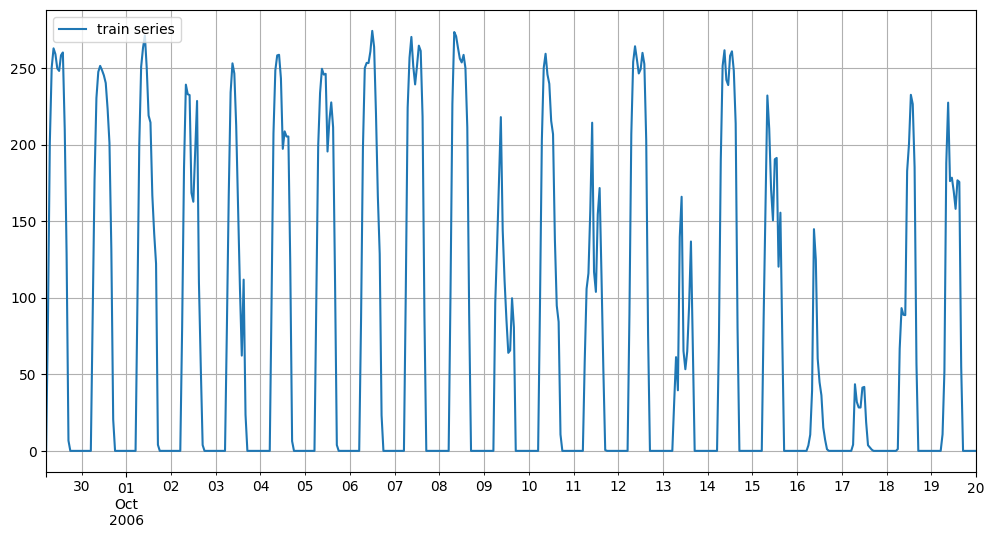

In [8]:
# Training dataset plot:

entry = next(iter(dataset.train))
train_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

train_series[-500:].plot() # Plot de los 500 ultimos (es mucho toda la serie)
plt.grid(which="both")
plt.legend(["train series"], loc="upper left")
plt.show()


C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\util.py:136: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  freq = start.freqstr


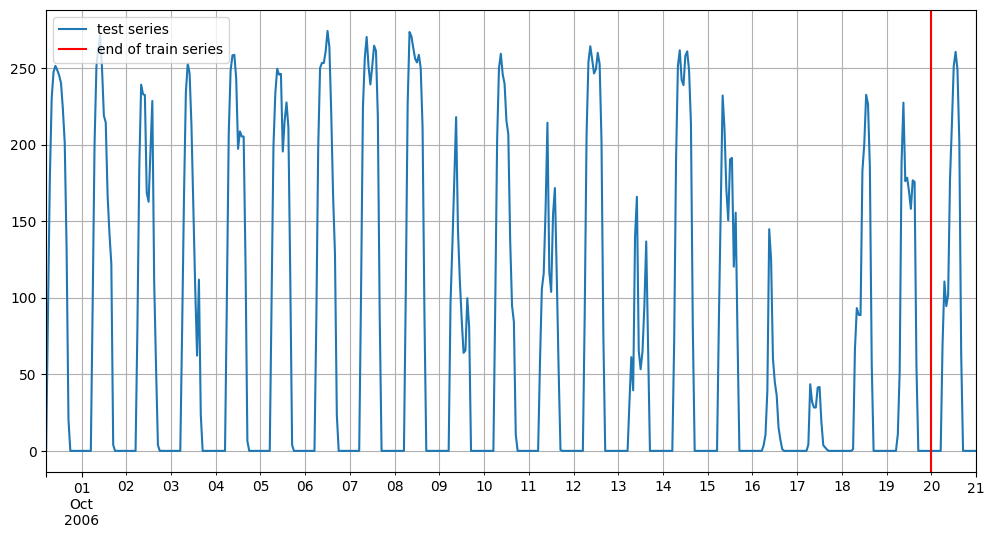

In [9]:
entry = next(iter(dataset.test))
test_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

test_series[-500:].plot()
plt.axvline(train_series.index[-1], color="r")  # end of train dataset
plt.grid(which="both")
plt.legend(["test series", "end of train series"], loc="upper left")
plt.show()

In [10]:
print(
    f"Length of forecasting window in test dataset: {len(test_series) - len(train_series)}"
)
print(f"Recommended prediction horizon: {dataset.metadata.prediction_length}")
print(f"Frequency of the time series: {dataset.metadata.freq}")

Length of forecasting window in test dataset: 24
Recommended prediction horizon: 24
Frequency of the time series: H


## Evaluator

In [11]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

## Modelo

In [16]:
#traffic
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)


In [12]:
#Solar nips
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [13]:
predictor = estimator.train(dataset_train, prefetch_factor = None)

  0%|          | 0/99 [00:00<?, ?it/s]C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:324: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  timestamp = pd.Timestamp(timestamp_input, freq=freq)
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:327: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  if isinstance(timestamp.freq, Tick):
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:329: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  timestamp.floor(timestamp.freq), timestamp.freq
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\common.py:328: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  return pd.Timestamp(
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:343: FutureWarning: Timest

# Samples

In [14]:
#Aqui hare el codigo para sacar las muestras por mi cuenta. sin el uso de la función make evaluation predictions
prediction_length = predictor.prediction_length
lead_time = predictor.lead_time
freq = predictor.freq

# CODIGO PERTENECIENTE A FUNCION MAKE EVALUATION PREDICTIONS:

from typing import Dict, Iterator, NamedTuple, Optional, Tuple
from gluonts.dataset.common import DataEntry, Dataset
def add_ts_dataframe(
        data_iterator: Iterator[DataEntry],
    ) -> Iterator[DataEntry]:
        for data_entry in data_iterator:
            data = data_entry.copy()
            index = pd.date_range(
                start=data["start"],
                freq=freq,
                periods=data["target"].shape[-1],
            )
            data["ts"] = pd.DataFrame(
                index=index, data=data["target"].transpose()
            )
            yield data

def ts_iter(dataset: Dataset) -> pd.DataFrame:
        for data_entry in add_ts_dataframe(iter(dataset)):
            yield data_entry["ts"]


def truncate_target(data):
        data = data.copy()
        target = data["target"]
        assert (
            target.shape[-1] >= prediction_length
        )  # handles multivariate case (target_dim, history_length)
        data["target"] = target[..., : -prediction_length - lead_time]
        return data

from gluonts.transform import AdhocTransform
dataset_trunc = AdhocTransform(truncate_target).apply(dataset_test)

forecast_it, ts_it = predictor.predict(dataset_trunc, num_samples=100), ts_iter(dataset_test)
forecasts = list(forecast_it)
targets = list(ts_it)



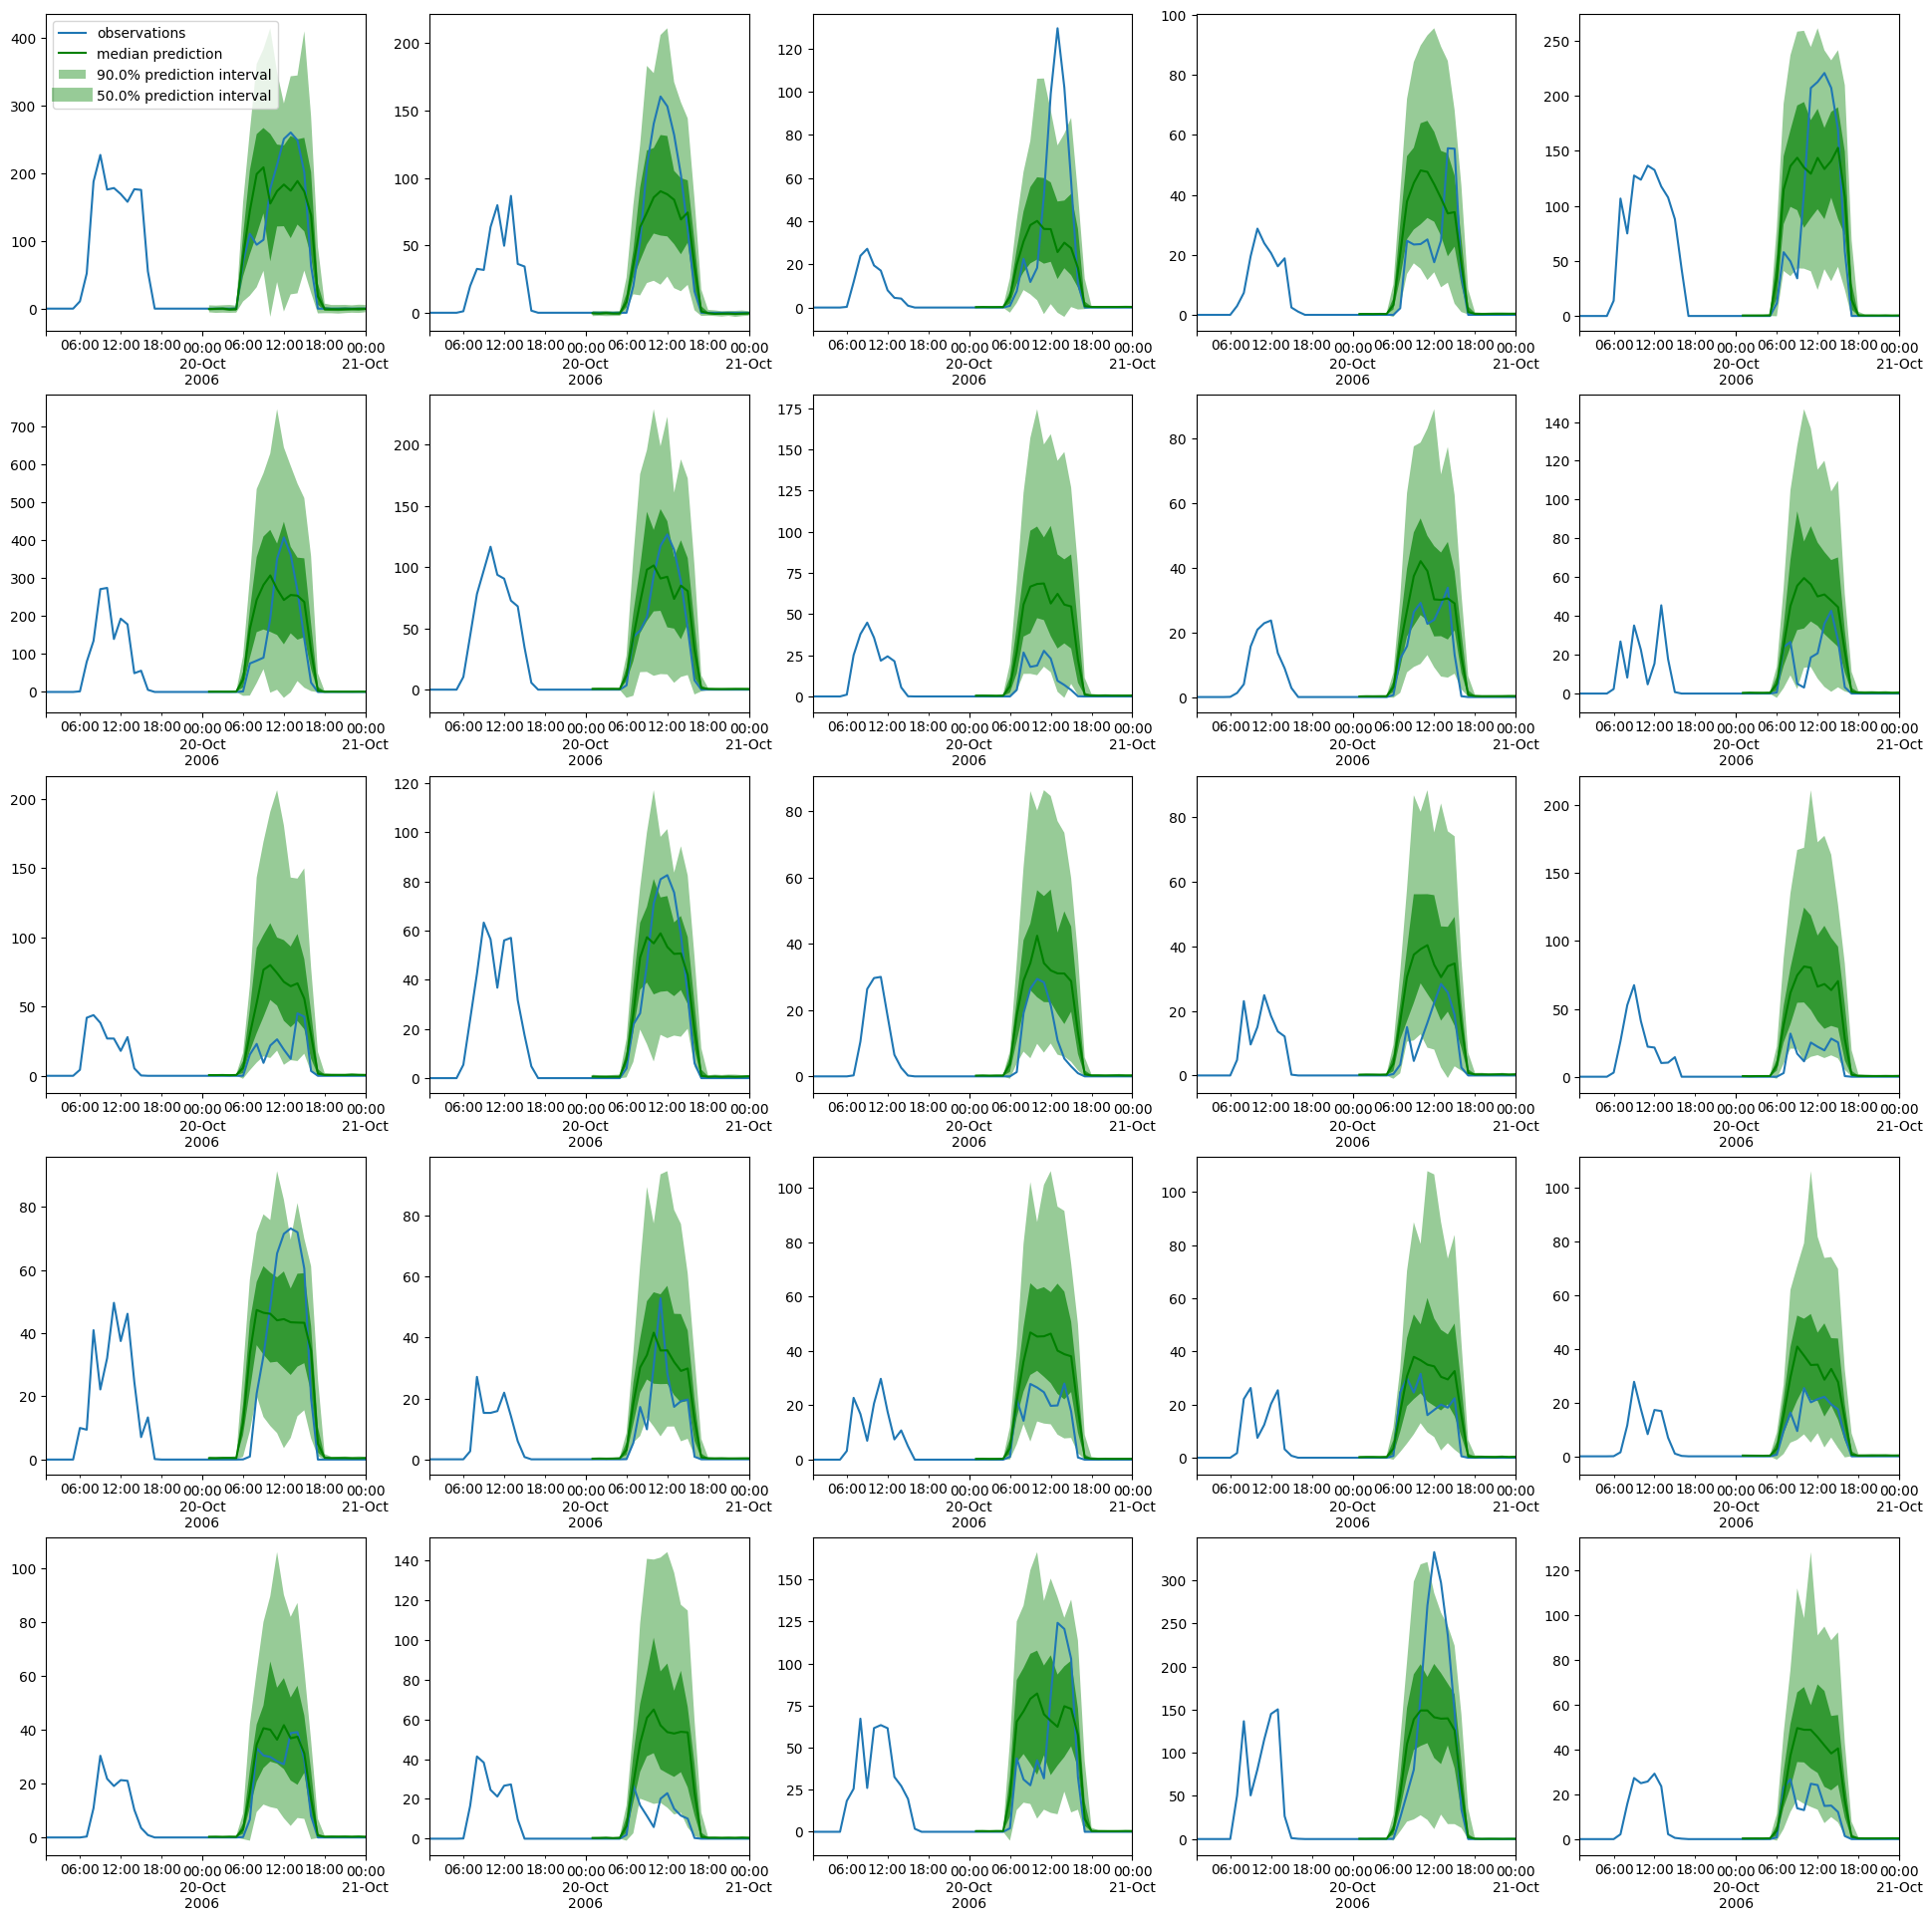

In [15]:
def plot(target, forecast, prediction_length, prediction_intervals=(50.0, 90.0), color='g', fname=None):
    label_prefix = ""
    rows = 5
    cols = 5
    fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
    axx = axs.ravel()
    seq_len, target_dim = target.shape

    ps = [50.0] + [
            50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
        ]

    percentiles_sorted = sorted(set(ps))

    def alpha_for_percentile(p):
        return (p / 100.0) ** 0.3

    for dim in range(0, min(rows * cols, target_dim)):
        ax = axx[dim]

        target[-2 * prediction_length :][dim].plot(ax=ax)

        ps_data = [forecast.quantile(p / 100.0)[:,dim] for p in percentiles_sorted]
        i_p50 = len(percentiles_sorted) // 2

        p50_data = ps_data[i_p50]
        p50_series = pd.Series(data=p50_data, index=forecast.index)
        p50_series.plot(color=color, ls="-", label=f"{label_prefix}median", ax=ax)

        for i in range(len(percentiles_sorted) // 2):
            ptile = percentiles_sorted[i]
            alpha = alpha_for_percentile(ptile)
            ax.fill_between(
                forecast.index,
                ps_data[i],
                ps_data[-i - 1],
                facecolor=color,
                alpha=alpha,
                interpolate=True,
            )
            # Hack to create labels for the error intervals.
            # Doesn't actually plot anything, because we only pass a single data point
            pd.Series(data=p50_data[:1], index=forecast.index[:1]).plot(
                color=color,
                alpha=alpha,
                linewidth=10,
                label=f"{label_prefix}{100 - ptile * 2}%",
                ax=ax,
            )

    legend = ["observations", "median prediction"] + [f"{k}% prediction interval" for k in prediction_intervals][::-1]
    axx[0].legend(legend, loc="upper left")

    if fname is not None:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)


import matplotlib.pyplot as plt
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

# IMPORTANCE SAMPLING EN UNA SERIE TEMPORAL

In [91]:
#trabajando con la primera serie
muestras = forecasts[0].samples
samples = muestras[:,:,10] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][10].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][10].index


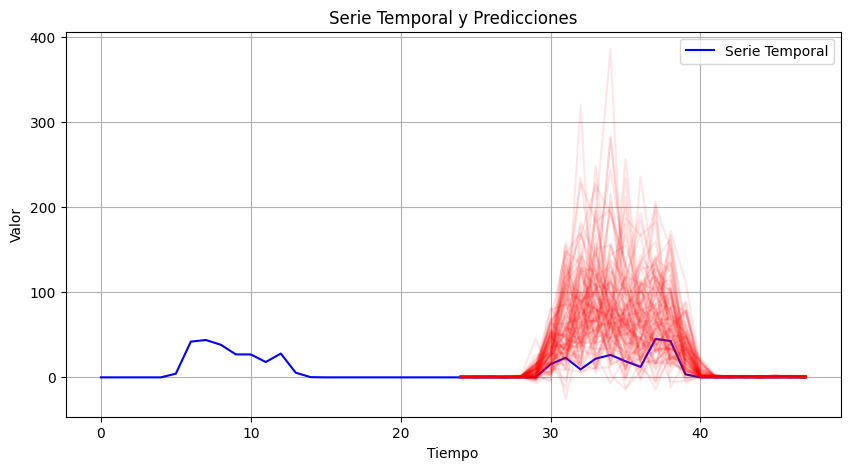

In [92]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(np.arange(48), target, label='Serie Temporal', color='blue')

# Graficar las predicciones encima de la serie temporal
for i in range(samples.shape[0]):
    plt.plot(np.arange(24) + 24, samples[i], color='red', alpha=0.1)  # Ajusta el rango x para que las predicciones se superpongan

plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Serie Temporal y Predicciones')
plt.legend()
plt.grid(True)
plt.show()

In [108]:
def rango_iqr(s, k, return_thresholds = False):
  # rango intercuantilico
  q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
  iqr = q75 - q25
  # Linea de corte.
  cut_off = iqr * k
  lower, upper = q25 - cut_off, q75 + cut_off
  print(f"Lower bound: {lower}\nUpper bound: {upper}")
  if return_thresholds:
      return lower, upper
  else: # identificar valores extremos
      return [True if x < lower or x > upper else False for x in s]
  
targets_df = pd.DataFrame()
targets_df["Target"] = target
targets_df.index = target_index

def graficar_extreme_values(k):

    targets_df["Extreme value"] = targets_df[["Target"]].apply(rango_iqr, k=k)
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

    col = np.where(targets_df['Extreme value'] == True, 'blue', 'silver')
    ax.scatter(targets_df.index, targets_df['Target'], c=col)
    ax.set_title('Extreme values para todos los años', size=18)
    ax.set_ylabel("Generacion [MW]")
    ax.set_xlabel('Fecha')

    plt.tight_layout()
    plt.show()

Lower bound: -18.22499990463257
Upper bound: 36.44999980926514


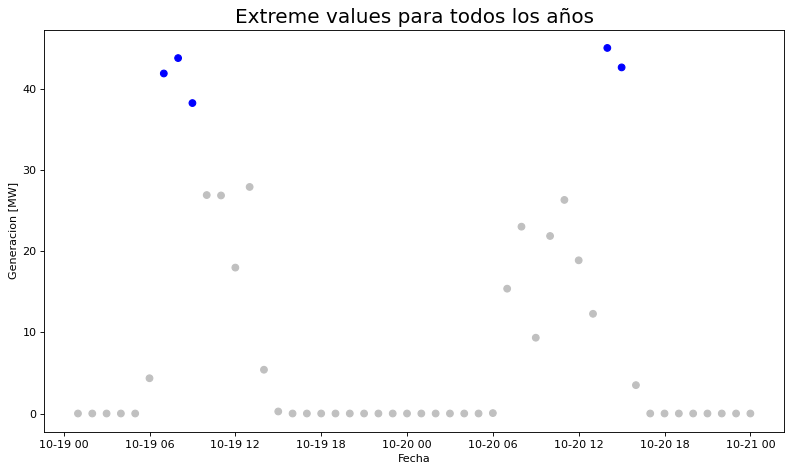

In [110]:
graficar_extreme_values(1)

In [112]:
def indicatriz(arr, alpha):
    if np.any(arr > alpha):
        return 1
    else:
        return 0
    
def MC(f, samples, alpha):
    sum = 0
    for i in range(samples.shape[0]):
        function_value = f(samples[i,:], alpha)
        sum+=function_value
    
    return (sum/samples.shape[0])


In [ ]:
MC(indicatriz, sampl)

# Pruebas distribución


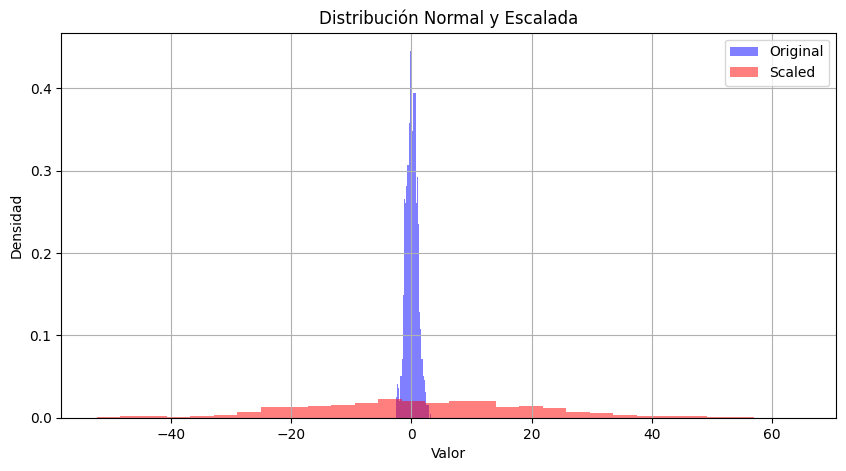

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar muestras de una distribución normal con media 0 y desviación estándar 1
mu = 0
sigma = 1
sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

# Graficar el histograma de las muestras originales
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=30, density=True, alpha=0.5, color='b', label='Original')

# Escalar las muestras
scaled_samples = samples * 20  # Escalar por un factor de 2

# Graficar el histograma de las muestras escaladas
plt.hist(scaled_samples, bins=30, density=True, alpha=0.5, color='r', label='Scaled')

plt.title('Distribución Normal y Escalada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

# UNIVARIADO

canela

In [112]:
canela = pd.read_csv("Datasets/canela_1.csv")
canela["Timestamp"] = pd.to_datetime(canela["GMT"], utc = True)
canela = canela.set_index("Timestamp")
canela = canela.drop("GMT", axis=1)
canela.columns = ["Generacion_MW"]
canela.index = canela.index.tz_convert(None).strftime('%Y-%m-%d %H:%M:%S')
canela = canela.loc["2009-11-10":"2015-07-18"] #Para que asi parta desde las 00:00 hasta 23:00

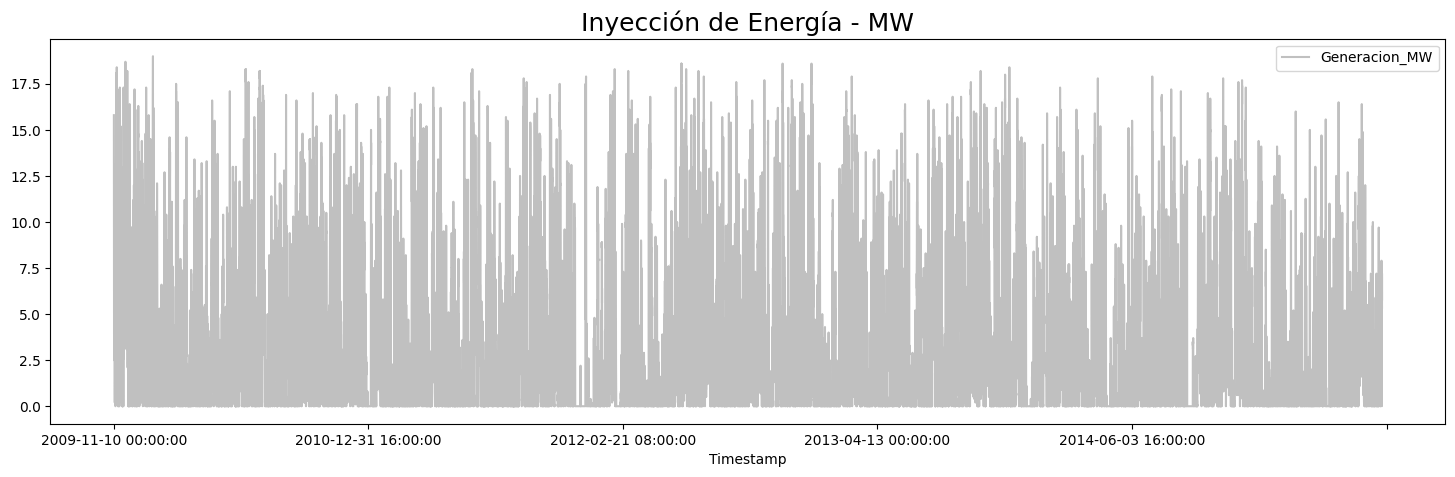

In [113]:
canela.Generacion_MW.plot(figsize=(18,5), color='silver', label='Generacion_MW')
plt.title('Inyección de Energía - MW', size=18)
plt.legend()
plt.show()

In [114]:
from gluonts.dataset.field_names import FieldName
from gluonts.dataset.artificial import ComplexSeasonalTimeSeries
from gluonts.dataset.common import ListDataset

In [115]:
target = canela.Generacion_MW
#target = np.expand_dims(target, axis=0)

In [116]:
target.shape

(49824,)

In [117]:
target

Timestamp
2009-11-10 00:00:00    15.8
2009-11-10 01:00:00    12.2
2009-11-10 02:00:00    10.4
2009-11-10 03:00:00    10.3
2009-11-10 04:00:00     7.7
                       ... 
2015-07-17 19:00:00     5.3
2015-07-17 20:00:00     5.3
2015-07-17 21:00:00     7.2
2015-07-17 22:00:00     5.5
2015-07-17 23:00:00     5.8
Name: Generacion_MW, Length: 49824, dtype: float64

In [118]:
prediction_length = 24

In [119]:
target.iloc[:-prediction_length]

Timestamp
2009-11-10 00:00:00    15.8
2009-11-10 01:00:00    12.2
2009-11-10 02:00:00    10.4
2009-11-10 03:00:00    10.3
2009-11-10 04:00:00     7.7
                       ... 
2015-07-16 19:00:00     6.8
2015-07-16 20:00:00     4.2
2015-07-16 21:00:00     3.5
2015-07-16 22:00:00     3.0
2015-07-16 23:00:00     3.5
Name: Generacion_MW, Length: 49800, dtype: float64

In [ ]:
#CASO DIMENSION AGREGADA.
train_ds = ListDataset(
    [{"start": canela.index[0], 
      "target": target[:, : -prediction_length]}],
    freq = "1H"
)

test_ds = ListDataset(
    [{"start": canela.index[0], 
      "target": target}],
    freq = "1H"
)

In [121]:
#CASO SIN AJUSTES.
train_ds = ListDataset(
    [{"start": canela.index[0], 
      "target": target.iloc[:-prediction_length]}],
    freq = "1H"
)

test_ds = ListDataset(
    [{"start": canela.index[0], 
      "target": target}],
    freq = "1H"
)

In [122]:
train_entry = next(iter(train_ds))
test_entry = next(iter(test_ds))

print(f"Variables que tiene el conjunto train: {train_entry.keys()}\nVariables que tiene el conjunto test: {test_entry.keys()}")

Variables que tiene el conjunto train: dict_keys(['start', 'target', 'source'])
Variables que tiene el conjunto test: dict_keys(['start', 'target', 'source'])


In [126]:
train_grouper = MultivariateGrouper(max_target_dim=1)

test_grouper = MultivariateGrouper(num_test_dates=int(len(test_ds)/len(train_ds)),
                                   max_target_dim=1)

In [127]:
dataset_train = train_grouper(train_ds)
dataset_test = test_grouper(test_ds)

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:106: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  timestamp + (len(data[FieldName.TARGET]) - 1) * timestamp.freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:108: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self.frequency = timestamp.freq
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:217: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:166: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:177: FutureWarning: Timestamp.

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\util.py:136: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  freq = start.freqstr


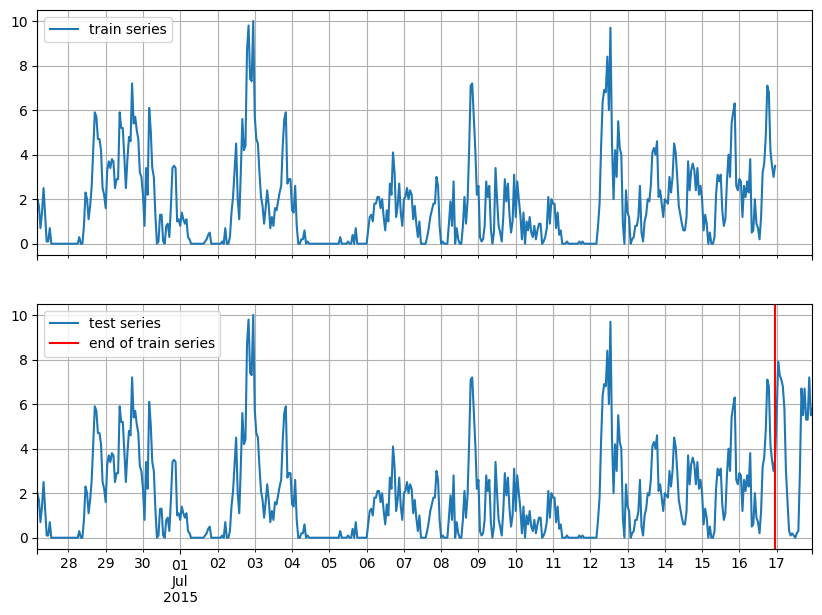

In [128]:
test_series = to_pandas(test_entry)
train_series = to_pandas(train_entry)

fig, ax = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 7))

train_series[-500:].plot(ax=ax[0])
ax[0].grid(which="both")
ax[0].legend(["train series"], loc="upper left")

test_series[-500:].plot(ax=ax[1])
ax[1].axvline(train_series.index[-1], color="r")  # end of train dataset
ax[1].grid(which="both")
ax[1].legend(["test series", "end of train series"], loc="upper left")

plt.show()

In [129]:
print(
    f"Length of forecasting window in test dataset: {len(test_series) - len(train_series)}"
)
print(f"Frequency of the time series: 1H")

Length of forecasting window in test dataset: 24
Frequency of the time series: 1H


In [130]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

In [131]:
#traffic
estimator = TempFlowEstimator(
    target_dim=1,
    prediction_length=24,
    cell_type='GRU',
    input_size=8,
    freq="1H",
    scaling=True,
    dequantize=True,
    n_blocks=4,
    trainer=Trainer(device=device,
                    epochs=45,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64,)
)
    

In [132]:
predictor = estimator.train(dataset_train, prefetch_factor = None)

  0%|          | 0/99 [00:00<?, ?it/s]C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:343: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self._freq_base = start.freq.base
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\split.py:36: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  return _shift_timestamp_helper(ts, ts.freq, offset)
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:384: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  ..., i0 : i0 + length * start.freq.n : start.freq.n
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:340: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self._freq_base is None or self._freq_base == start.freq.base
 27%|██▋       | 27/99 [00:02<00:06, 11.69it/s, epoch=9/45, avg_loss=1.92]


KeyboardInterrupt: 

In [135]:
next(iter(dataset_train))["target"].shape

(1, 49800)

In [ ]:
#input_size=taget_dim+target_dim*len(lags_seq)+len(time_feat)
#target=137, len(lags_seq)=3, and len(time_feat)=4, so the input_size=137+137x3+4=552